In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from typing import Callable
from IPython.display import Image

# Бассейны Ньютона
Фрактал Ньютона - это ограниченное множество на комплексной плоскости, которое описывется применением **метода Ньютона** к полиномиальной функции $p(z)\in\mathbb{C}[z]$ или трансцендентной функции. Фрактальные области появляются при нахождении приближённых корней нелинейного уравнения при помощи метода Ньютона на комплексной плоскости.

_Справка:_


Метод Ньютона - итерационный численный алгоритм нахождения нуля заданной функции по начальному приближению.Он заключается в последовательном применении следующей формулы до тех пор, пока не будет достигнута необходимая точность приближённого решения:
$$
z_{n+1}=z_n-\frac{f(z_n)}{f'(z_n)}
$$
Подробно останавливаться на этом не будем, но посмотрим на визуализация данного метода. Мы построили его так же в вещественной плоскости, потому что так более наглядно, визуализировать функцию из $f:\mathbb{C}\rightarrow\mathbb{C}$ не так удобно.

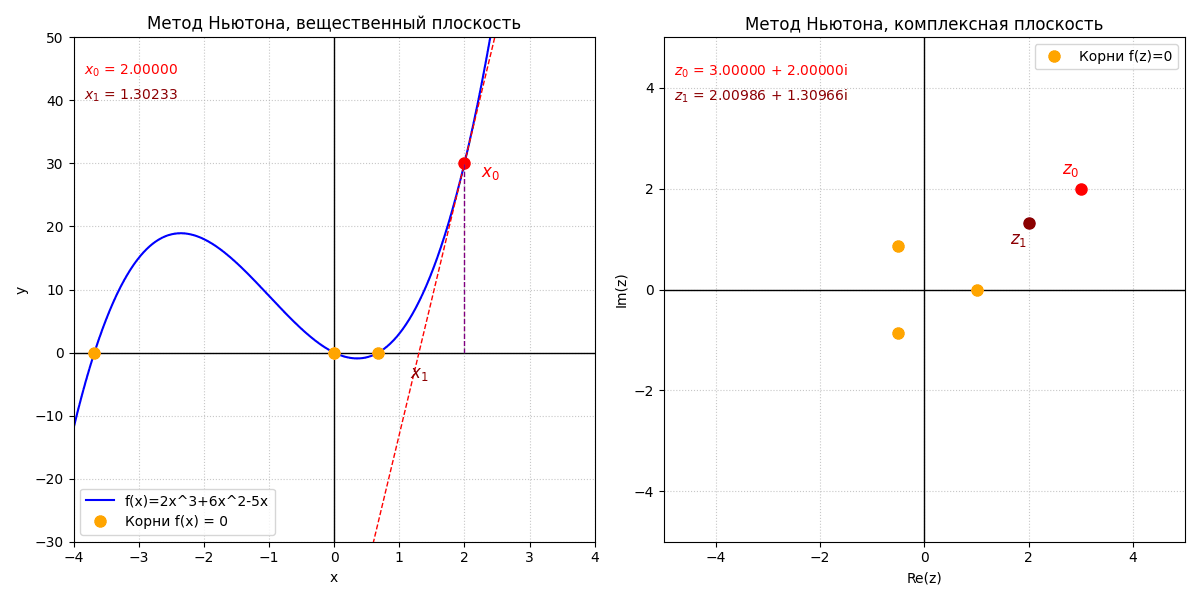

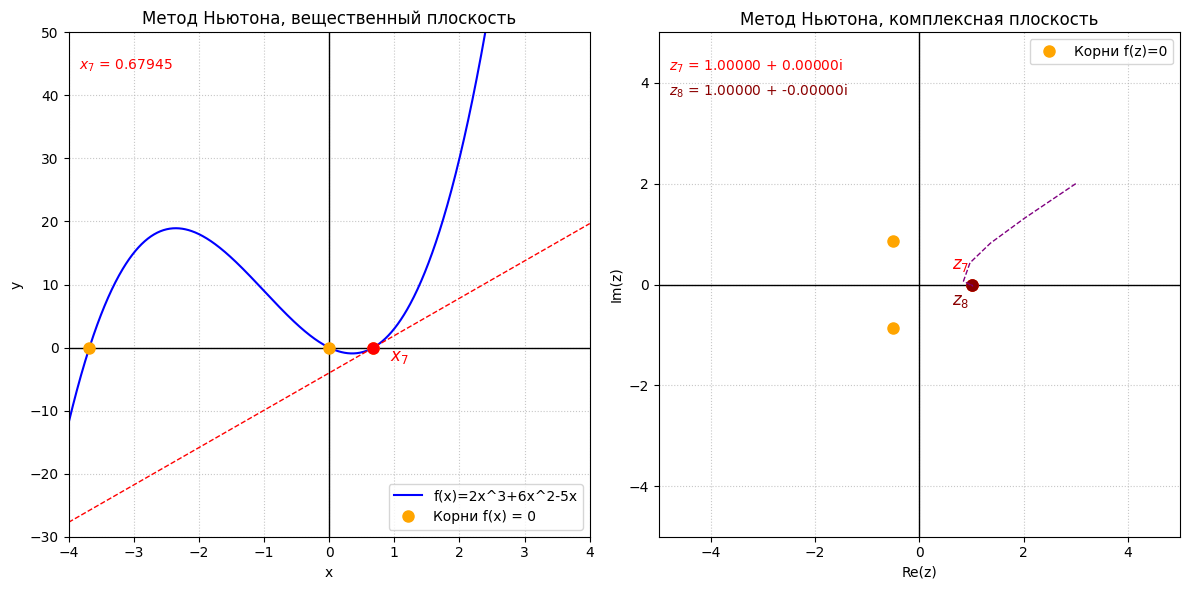

In [2]:
def Newton_method(z_0: float, # Начальное приближение
        f: Callable[[float], float], # f(z)
        f_derivative: Callable[[float], float], # f'(z)
        max_iter: int, # Максимальное число итераций
        tol: float=1e-9 # Точность
        ):
    result = [z_0]
    for i in range(max_iter):
        if abs(f(result[i])) < tol:
            break
        result.append(result[i] -f(result[i]) / f_derivative(result[i])) 
        
    return result

def example_func(x):
    return 2 * x ** 3 + 6 * x ** 2 - 5 * x
def example_func_d(x):
    return 6 * x ** 2 + 12 * x - 5 
  
def example_complex_func(z):
    return z ** 3 - 1
def example_complex_func_d(z):
    return 3 * z ** 2

x_0 = 2.0
z_0 = 3 + 2j

iters = Newton_method(x_0, example_func, example_func_d, 10)
iters_complex = Newton_method(z_0, example_complex_func, example_complex_func_d, 10)

fig, (ax_real, ax_complex) = plt.subplots(1, 2, figsize=(12, 6))

# Вещественная плоскость
x = np.linspace(-4, 4, 1000)
y = example_func(x)
ax_real.axhline(0, color='black', lw=1)
ax_real.axvline(0, color='black', lw=1)
ax_real.plot(x, y, 'blue', label='f(x)=2x^3+6x^2-5x')

roots = np.roots([2, 6, -5, 0])
real_roots = roots[np.isreal(roots)].real
ax_real.plot(real_roots, np.zeros_like(real_roots), 'o', color='orange', markersize=8, label='Корни f(x) = 0')

point_real, = ax_real.plot([], [], 'ro', markersize=8)
tangent_line, = ax_real.plot([], [], 'r--', lw=1)
vertical_line, = ax_real.plot([], [], color="purple", linestyle="--", lw=1)

text_xn = ax_real.text(0, 0, '', color='red', fontsize=12, ha='center', va='bottom')
text_xn1 = ax_real.text(0, 0, '', color='darkred', fontsize=12, ha='center', va='top')

ax_real.set_title('Метод Ньютона, вещественный плоскость')
ax_real.set_xlabel('x')
ax_real.set_ylabel('y')
ax_real.set_xlim(-4, 4)
ax_real.set_ylim(-30, 50)
ax_real.grid(True, linestyle=':', alpha=0.7)

legend_xn = ax_real.text(0.02, 0.95, '', transform=ax_real.transAxes,
    fontsize=10, color='red', va='top')
legend_xn1 = ax_real.text(0.02, 0.90, '', transform=ax_real.transAxes,
    fontsize=10, color='darkred', va='top')
ax_real.legend()

# Комплексная плоскость
ax_complex.axhline(0, color='black', lw=1)
ax_complex.axvline(0, color='black', lw=1)

roots_complex = np.roots([1, 0, 0, -1])
ax_complex.plot(roots_complex.real, roots_complex.imag, 'o', color='orange', markersize=8, label='Корни f(z)=0')

legend_zn = ax_complex.text(0.02, 0.95, '', transform=ax_complex.transAxes,
    fontsize=10, color='red', va='top')

ax_complex.set_xlim(-5, 5)
ax_complex.set_ylim(-5, 5)
ax_complex.set_title('Метод Ньютона, комплексная плоскость')
ax_complex.set_xlabel('Re(z)')
ax_complex.set_ylabel('Im(z)')
ax_complex.grid(True, linestyle=':', alpha=0.7)
legend_zn_current = ax_complex.text(0.02, 0.95, '', transform=ax_complex.transAxes,
                                   fontsize=10, color='red', va='top')
legend_zn_next = ax_complex.text(0.02, 0.90, '', transform=ax_complex.transAxes,
                                fontsize=10, color='darkred', va='top')
ax_complex.legend(loc='upper right')

point_complex_current, = ax_complex.plot([], [], 'o', color='red', markersize=8)
point_complex_next, = ax_complex.plot([], [], 'o', color='darkred', markersize=8)
path_complex, = ax_complex.plot([], [], color='purple', linestyle='--', lw=1)
text_zn = ax_complex.text(0, 0, '', color='red', fontsize=12, ha='center', va='bottom')
text_zn1 = ax_complex.text(0, 0, '', color='darkred', fontsize=12, ha='center', va='bottom')

def update(frame):
    z = iters[frame]
    fx = example_func(z)
    fpx = example_func_d(z)

    tangent_x = np.linspace(-4, 4, 2)
    tangent_y = fx + fpx * (tangent_x - z)
    point_real.set_data([z], [fx])
    tangent_line.set_data(tangent_x, tangent_y)
    vertical_line.set_data([z, z], [0, fx])

    text_xn.set_position((z + 0.4, fx - 3))
    text_xn.set_text(f"$x_{{{frame}}}$")

    if frame + 1 < len(iters):
        x_next = iters[frame + 1]
        text_xn1.set_position((x_next, -2))
        text_xn1.set_text(f"$x_{{{frame+1}}}$")
        legend_xn.set_text(f"$x_{{{frame}}}$ = {z:.5f}")
        legend_xn1.set_text(f"$x_{{{frame+1}}}$ = {x_next:.5f}")
    else:
        text_xn1.set_text('')
        legend_xn.set_text(f"$x_{{{frame}}}$ = {z:.5f}")
        legend_xn1.set_text('')

    zc = iters_complex[frame]
    point_complex_current.set_data([zc.real], [zc.imag])
    text_zn.set_position((zc.real - 0.2, zc.imag + 0.2))
    text_zn.set_text(f"$z_{{{frame}}}$")

    re_vals = [p.real for p in iters_complex[:frame+1]]
    im_vals = [p.imag for p in iters_complex[:frame+1]]
    path_complex.set_data(re_vals, im_vals)

    if frame + 1 < len(iters_complex):
        z_next = iters_complex[frame + 1]
        point_complex_next.set_data([z_next.real], [z_next.imag])
        text_zn1.set_position((z_next.real - 0.2, z_next.imag - 0.5))
        text_zn1.set_text(f"$z_{{{frame+1}}}$")
        legend_zn_current.set_text(f"$z_{{{frame}}}$ = {zc.real:.5f} + {zc.imag:.5f}i")
        legend_zn_next.set_text(f"$z_{{{frame+1}}}$ = {z_next.real:.5f} + {z_next.imag:.5f}i")
    else:
        point_complex_next.set_data([], [])
        text_zn1.set_text('')
        legend_zn_current.set_text(f"$z_{{{frame}}}$ = {zc.real:.5f} + {zc.imag:.5f}i")
        legend_zn_next.set_text('')


    return (point_real, tangent_line, vertical_line, text_xn, text_xn1,
            legend_xn, legend_xn1,
            point_complex_current, point_complex_next, path_complex, text_zn, text_zn1)

ani = FuncAnimation(fig, update, frames=len(iters), interval=800, blit=True, repeat=False)

plt.tight_layout()
ani.save('newton_method_animation.gif', writer='pillow', fps=1)
Image(filename='newton_method_animation.gif')

##### Что же представляет из себя фрактал Ньютона?
По сути, данный объект есть ничто иное, как области, при выборе начальных точек для алгоритма Ньютона в которых, метод сойдется к тому или иному корню. Можно назвать их областями притяжения каждого из корней. Построим визуализацию.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2].


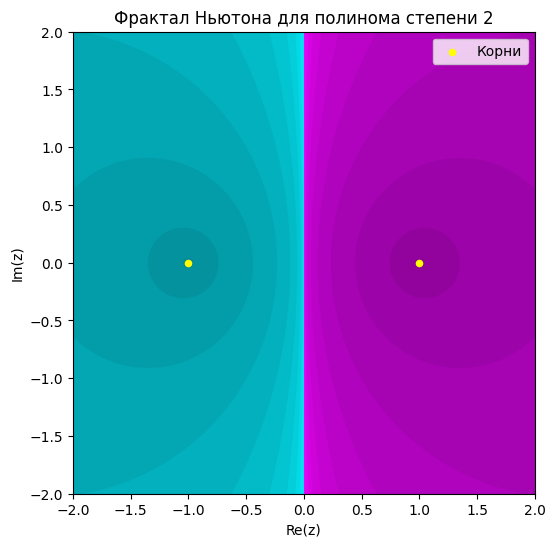

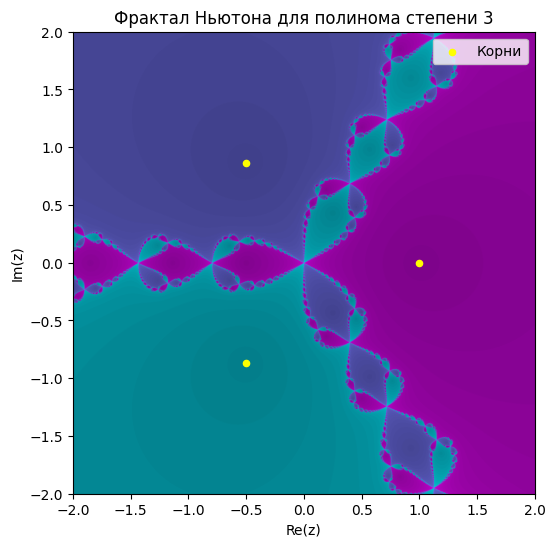

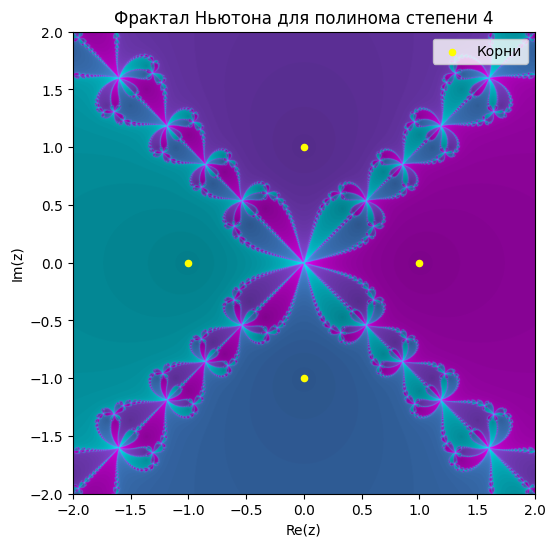

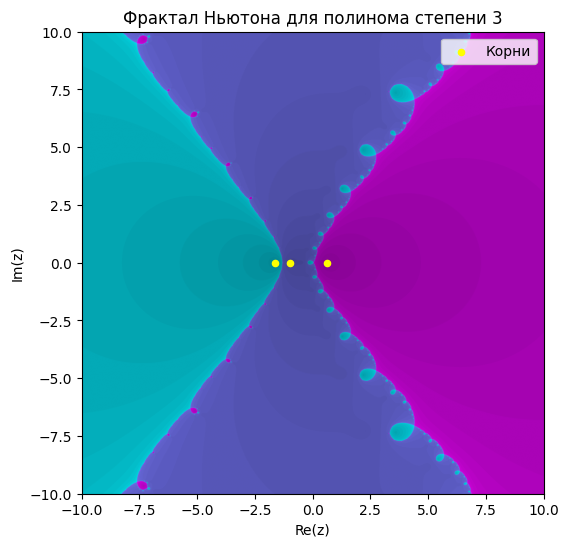

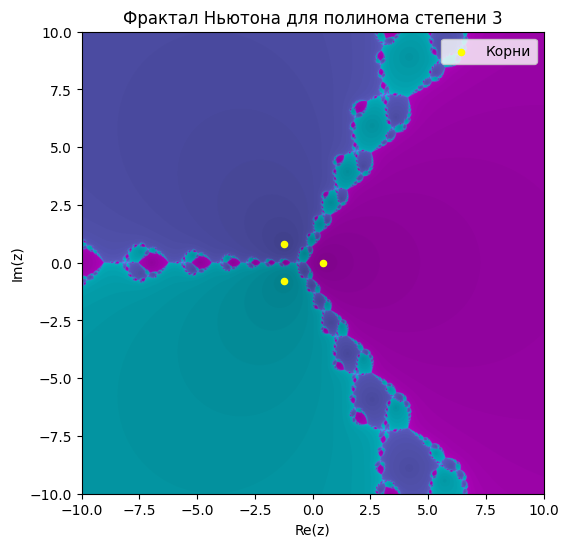

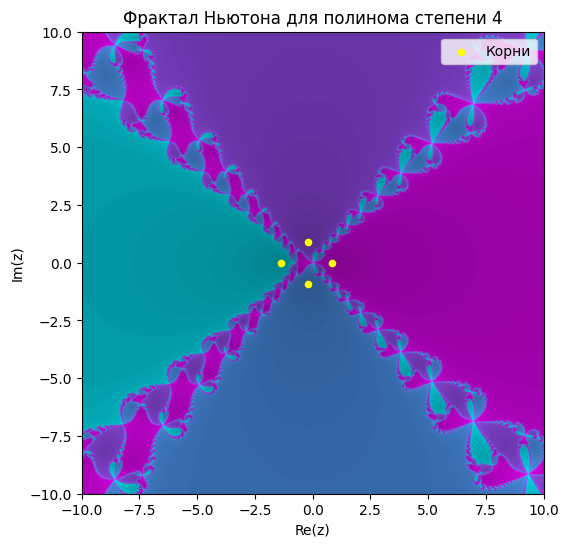

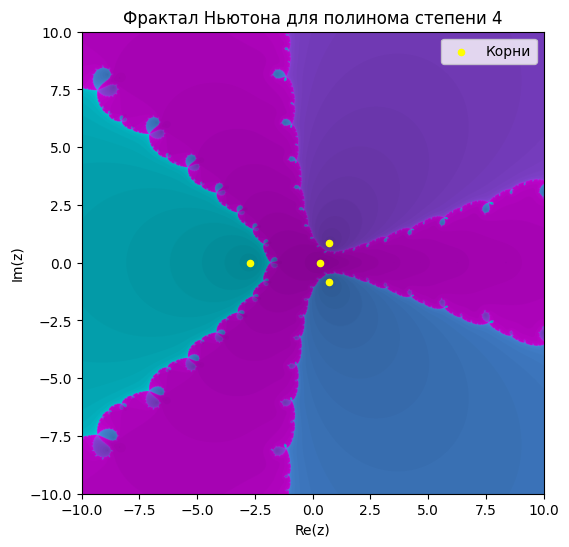

In [3]:
def newton_fractal(coeffs: list, x_range: tuple, y_range: tuple,
        resolution: int=3000,
        max_iter: int=50, tol: float=1e-6, cmap: str='cool'):
    x = np.linspace(x_range[0], x_range[1], resolution)
    y = np.linspace(y_range[0], y_range[1], resolution)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    roots = np.roots(coeffs)
    def f(z):
        return np.polyval(coeffs, z)
    def f_der(z):
        return np.polyval(np.polyder(coeffs), z)

    Z_iter = Z.copy()
    index_map = np.zeros(Z.shape, dtype=int)
    iter_count = np.zeros(Z.shape)

    for k in range(max_iter):
        not_converged = np.abs(f(Z_iter)) > tol
        Z_iter[not_converged] -= f(Z_iter[not_converged]) / f_der(Z_iter[not_converged])
        iter_count[not_converged] = k + 1


    for i, r in enumerate(roots):
        mask = np.abs(Z_iter - r) < tol
        index_map[mask] = i

    cmap_obj = plt.get_cmap(cmap, len(roots))
    base_colors = cmap_obj(index_map / len(roots))

    brightness = iter_count / iter_count.max()
    fractal_rgb = base_colors.copy()
    fractal_rgb[..., :3] = fractal_rgb[..., :3] * (0.5 + 0.7 * brightness[..., np.newaxis])

    fig, ax = plt.subplots(figsize=(6, 6), facecolor="white")
    ax.set_facecolor('#1D1D96')
    ax.imshow(fractal_rgb, extent=(x_range[0], x_range[1], y_range[0], y_range[1]), alpha=0.9)

    ax.scatter(roots.real, roots.imag, color='yellow', s=20, alpha=1.0, label="Корни")

    ax.set_title(f"Фрактал Ньютона для полинома степени {len(coeffs)-1}", color='black')
    ax.set_xlabel("Re(z)", color='black')
    ax.set_ylabel("Im(z)", color='black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')

    ax.grid(False)
    ax.legend(facecolor='white')

    plt.savefig(f"Newton_fractal_{coeffs}.png", dpi=900)

newton_fractal([1, 0, -1], x_range=(-2, 2), y_range=(-2, 2))
newton_fractal([1, 0, 0, -1], x_range=(-2, 2), y_range=(-2, 2))
newton_fractal([1, 0, 0, 0, -1], x_range=(-2, 2), y_range=(-2, 2))
newton_fractal([1, 2, 0, -1], x_range=(-10, 10), y_range=(-10, 10))
newton_fractal([1, 2, 1, -1], x_range=(-10, 10), y_range=(-10, 10))
newton_fractal([1, 1, 0, 0, -1], x_range=(-10, 10), y_range=(-10, 10))
newton_fractal([1, 1, -3, 4, -1], x_range=(-10, 10), y_range=(-10, 10))